# Polynimial Regression

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

Text(0, 0.5, 'Y dataset')

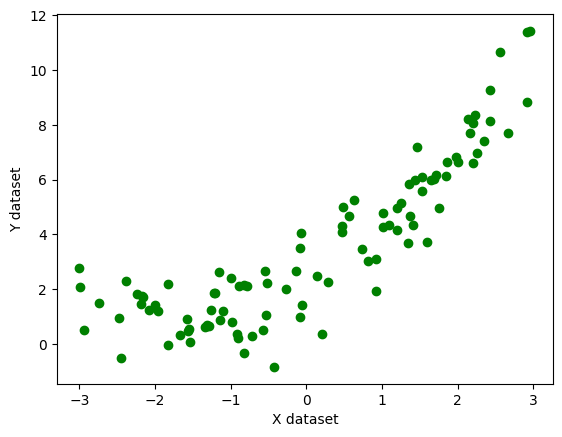

In [5]:
X = 6 * np.random.rand(100,1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# This is quadratic equation used - y= 0.5x^2 + 1.5x + 2  + outliers
plt.scatter(X, y, color = 'g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.20, random_state= 42)

In [8]:
# implementing simple linear equation
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [9]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
from sklearn.metrics import r2_score
score = r2_score(y_test, regression.predict(X_test))
print(score)

0.03666195406403505


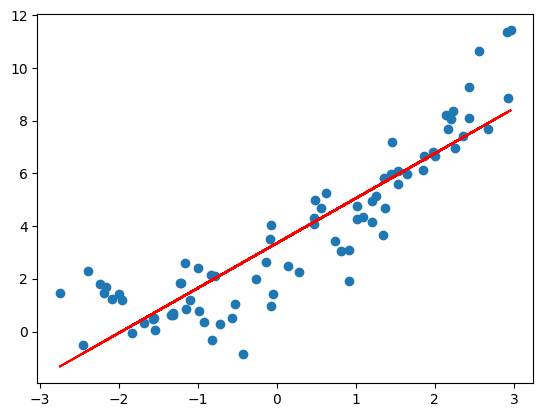

In [15]:
# visualizing the model
plt.plot(X_train, regression.predict(X_train), color = 'r')
plt.scatter(X_train, y_train)

In [16]:
# Applying polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [17]:
poly = PolynomialFeatures(degree=2, include_bias= True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [18]:
X_train_poly

array([[ 1.00000000e+00, -1.14285080e+00,  1.30610794e+00],
       [ 1.00000000e+00, -2.23852774e+00,  5.01100643e+00],
       [ 1.00000000e+00, -1.40454189e-01,  1.97273792e-02],
       [ 1.00000000e+00, -5.69381529e-01,  3.24195325e-01],
       [ 1.00000000e+00, -1.31273096e+00,  1.72326259e+00],
       [ 1.00000000e+00,  2.42566029e+00,  5.88382782e+00],
       [ 1.00000000e+00, -1.53562013e+00,  2.35812918e+00],
       [ 1.00000000e+00, -1.20917786e+00,  1.46211109e+00],
       [ 1.00000000e+00,  1.33822879e+00,  1.79085629e+00],
       [ 1.00000000e+00,  2.26046028e+00,  5.10968068e+00],
       [ 1.00000000e+00,  9.14268452e-01,  8.35886803e-01],
       [ 1.00000000e+00,  1.41145514e-01,  1.99220562e-02],
       [ 1.00000000e+00,  2.66939088e+00,  7.12564767e+00],
       [ 1.00000000e+00, -7.62021469e-02,  5.80676719e-03],
       [ 1.00000000e+00, -5.26765348e-02,  2.77481731e-03],
       [ 1.00000000e+00,  1.65327320e+00,  2.73331229e+00],
       [ 1.00000000e+00,  2.22410706e+00

In [22]:
# implementing simple linear equation
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print (score)

0.7136753244284127


In [20]:
# Applying for degree = 3
poly = PolynomialFeatures(degree=3, include_bias= True)
X_train_poly3 = poly.fit_transform(X_train)
X_test_poly3 = poly.transform(X_test)

In [23]:
# implementing simple linear equation
from sklearn.metrics import r2_score
regression1 = LinearRegression()
regression1.fit(X_train_poly3, y_train)
y_pred = regression1.predict(X_test_poly3)
score = r2_score(y_test, y_pred)
print (score)

0.7039253279873885


In [24]:
print(regression.coef_)

[[0.         1.53673397 0.42661616]]


In [25]:
print(regression1.coef_)

[[ 0.          1.63320604  0.43942083 -0.02203135]]


In [26]:
print (regression.intercept_)
print (regression1.intercept_)

[2.31069422]
[2.29051345]


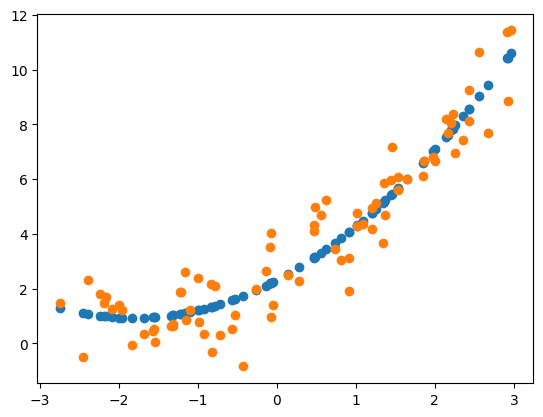

In [29]:
plt.scatter(X_train, regression.predict(X_train_poly))
plt.scatter(X_train, y_train)

In [30]:
# prediction for new dataset
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)

In [31]:
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

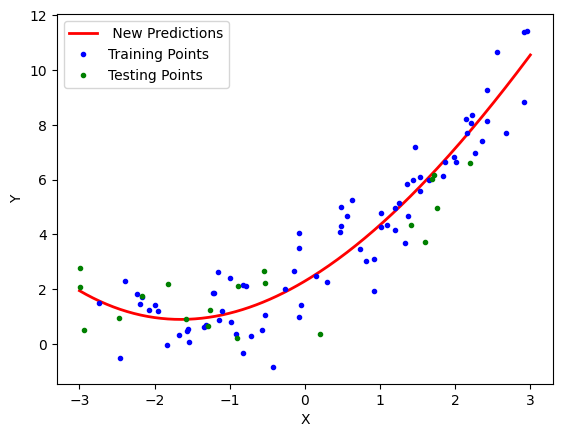

In [35]:
y_new = regression1.predict(X_new_poly)
plt.plot(X_new, y_new, 'r-', linewidth = 2, label = ' New Predictions')
plt.plot(X_train, y_train, 'b.', label = 'Training Points')
plt.plot(X_test, y_test, 'g.', label ="Testing Points")
plt.xlabel("X")
plt.ylabel('Y')
plt.legend()
plt.show()

# Pipeline Concepts

In [36]:
from sklearn.pipeline import Pipeline

In [ ]:
def poly_regression(degree):
    X_new = np.linspace(-3,3,200).reshape(200,1)

    poly_features = PolynomialFeatures(degree = degree, include_bias= True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([
        ('poly_features', poly_features),   # creates polynimial features
        ('lin_reg', lin_reg)                # uses regression here
    ])
    poly_regression.fit(X_train, y_train)
    y_pred_new = poly_regression.predict(X_new)

    # plotting the data now
    plt.plot(X_new, y_pred_new, 'r', label = "Degree" + str(degree), linewidth = 2)
    plt.plot(X_train, y_train, 'b.', linewidth = 3, label = 'training data')
    plt.plot(X_test, y_test, 'g.', linewidth = 3, label = 'test data')
    plt.legend(loc = 'upper left')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.axis([-4,4,0,10])
    plt.show()

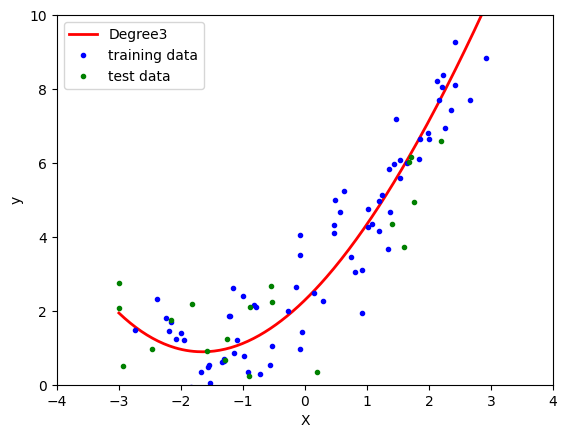

In [57]:
poly_regression(3)